<a href="https://colab.research.google.com/github/sriharikk/Deep-Learning/blob/main/DL_exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1, Loss: 0.0269
Epoch 2, Loss: 0.0159
Epoch 3, Loss: 0.0130
Epoch 4, Loss: 0.0114
Epoch 5, Loss: 0.0104
Epoch 6, Loss: 0.0093
Epoch 7, Loss: 0.0084
Epoch 8, Loss: 0.0082
Epoch 9, Loss: 0.0071
Epoch 10, Loss: 0.0068


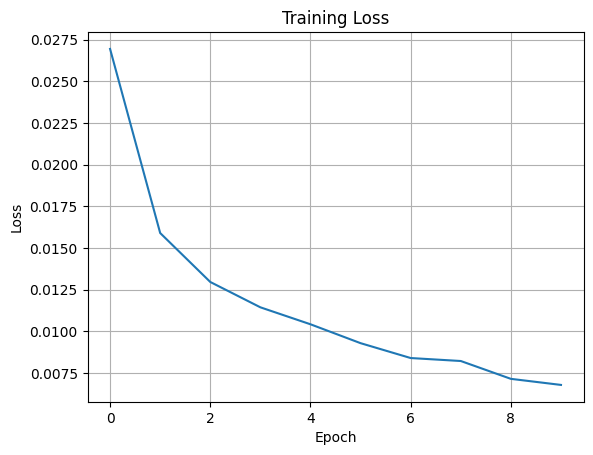

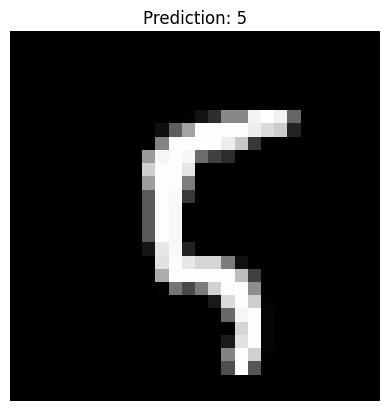

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder


# Step 1: Load MNIST dataset
(X_train, y_train), (_, _) = mnist.load_data()


# Step 2: Preprocess images
# Convert 28x28 images into 784 values
# Normalize pixel values from 0-255 to 0-1
X_train = X_train.reshape(-1, 784) / 255.0


# Step 3: One-hot encode the target labels
encoder = OneHotEncoder(sparse_output=False)

y_train = encoder.fit_transform(
    y_train.reshape(-1, 1)
)


# Step 4: Define neural network sizes
input_size = 784
hidden_size = 64
output_size = 10


# Step 5: Initialize weights and biases
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))


# Step 6: Define sigmoid activation function
sigmoid = lambda x: 1 / (1 + np.exp(-x))

sigmoid_deriv = lambda x: x * (1 - x)


# Step 7: Define loss function
loss_fn = lambda y, y_hat: -np.mean(
    y * np.log(y_hat + 1e-8)
)


# Step 8: Training settings
epochs = 10
lr = 0.1

losses = []


# Step 9: Train the neural network
for epoch in range(epochs):

    total_loss = 0

    for i in range(X_train.shape[0]):

        # Get one training sample
        x = X_train[i:i+1]
        y = y_train[i:i+1]


        # -------------------------
        # Forward Propagation
        # -------------------------

        # Hidden layer
        z1 = x @ W1 + b1
        a1 = sigmoid(z1)


        # Output layer
        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)


        # Calculate loss
        loss = loss_fn(y, a2)

        total_loss += loss


        # -------------------------
        # Backpropagation
        # -------------------------

        dz2 = a2 - y

        dW2 = a1.T @ dz2
        db2 = dz2


        dz1 = (dz2 @ W2.T) * sigmoid_deriv(a1)

        dW1 = x.T @ dz1
        db1 = dz1


        # -------------------------
        # Update weights and biases
        # -------------------------

        W2 -= lr * dW2
        b2 -= lr * db2

        W1 -= lr * dW1
        b1 -= lr * db1


    # Average loss for this epoch
    epoch_loss = total_loss / X_train.shape[0]

    losses.append(epoch_loss)

    print(
        f"Epoch {epoch + 1}, "
        f"Loss: {epoch_loss:.4f}"
    )


# Step 10: Plot training loss
plt.plot(losses)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()


# Step 11: Prediction function
def predict(img):

    # Convert image to 784 values
    img = img.reshape(1, 784) / 255.0


    # Forward propagation
    a1 = sigmoid(img @ W1 + b1)

    a2 = sigmoid(a1 @ W2 + b2)


    # Return class with highest output
    return np.argmax(a2)


# Step 12: Test prediction
idx = 100


# Display image
plt.imshow(
    X_train[idx].reshape(28, 28),
    cmap='gray'
)

plt.title(
    f"Prediction: {predict(X_train[idx])}"
)

plt.axis('off')

plt.show()